<a href="https://colab.research.google.com/github/CesarJardines/icd2026/blob/main/an%C3%A1lisis_datos_ANUIES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1: Análisis exploratorio de dataset



César Eduardo Jardines Mendoza
Cuatrimestre III-2026
CICESE

### Descripción del contexto y procedencia del dataset

Para esta práctica se utilizó un dataset extraido del sitio [Data México](https://www.economia.gob.mx/datamexico/) el cual consta de una estructura de datos organizado que escogí del [sector educación](https://www.economia.gob.mx/datamexico/es/vizbuilder?cube=anuies_status&drilldowns%5B0%5D=Career+Fields.Career&drilldowns%5B1%5D=Campus&drilldowns%5B2%5D=Year&drilldowns%5B3%5D=Sex&drilldowns%5B4%5D=Geography+Municipality.Geography.State&drilldowns%5B5%5D=Academic+Degree&measures%5B0%5D=Students). El sitio define que la fuente de los datos proviene de [Asociación Nacional de Universidades e Instituciones de Educación Superior (ANUIES)](https://www.anuies.mx/informacion-y-servicios/informacion-estadistica-de-educacion-superior/anuario-estadistico-de-educacion-superior), el año de recolección de los datos abarca los años 2018 a 2022. En cuanto a la licencia de uso encontré que en el sitio [Data México]() en el apartado de [términos y condiciones](https://www.gob.mx/terminos) mencionan que *Se autoriza al Usuario a visualizar y descargar los materiales contenidos en el sitio solamente para su uso personal y no para un uso comercial.*

El dataset que se descargó cuenta con 282215 columnas y 12 atributos, la descripción se puede observar en la tabla.

|      Atributo  |    Descripción                | Categoría | Tipo |
|----------------|-------------------------------|------------------|-----------|
|Career ID| Identificador único de la carrera    | nominal|str|
|Career   | Nombre del programa académico o carrera   |nominal|str |
|Campus ID |Identificador numérico único del plantel o campus|nominal| int |
|Campus     | Nombre del campus o sede del plantel |nominal | str |
|Year       |Año | continuo| int |
|Sex ID         |Identificador del sexo (1 = Hombre, 2 = Mujer)|nominal| int |
|Sex          |Tipo de sexo|nominal| str |
|State ID          |Identificador del estado |nominal| int |
|State          |Nombre del estado|nominal| str |
|Academic Degree ID          |Código numérico del nivel o grado académico del programa |ordinal| int |
|Academic Degree          |Descripción textual del grado académico|ordinal| str |
|Students          |Número total de estudiantes|continuo| int |


### Descripción del contexto y procedencia del dataset

El dataset muestra la matrícula de aquellos estudiantes inscritos en instituciones de educación superiro en México por estado, carrera, campus, sexo y grado académico.



### Verificación de la estructura

Para confirmar que el dataset cumple
con los requisitos mínimos establecidos para la práctica empezaremos a importar las bibliotecas correspondientes

In [28]:
import pandas as pd # Manipulación y transformación de datos
import numpy as np # Operaciones matemáticas y a arreglos
import matplotlib.pyplot as plt # Motor base de graficación
import seaborn as sns # Biblioteca de visualización de datos


Empezamos a cargar el dataset leyendo el .csv con la biblioteca pandas.

In [29]:
# Cargamos el dataset
df = pd.read_csv("/datos.csv")

Verificamos las dimenciones del dataset para corroborar que cumpla con el número mínimo establecido. Para lograrlo usaremos la función `shape` la cual nos ayudará a obtener las dimenciones.

In [30]:
# Devolvermos la cantidad de filas y columnas
n_filas, n_columnas = df.shape
print(f"Dimensiones: {n_filas} filas, {n_columnas} columnas" )

Dimensiones: 282214 filas, 12 columnas


Verificaremos los tipos de datos de los atributos de nuestro dataset, nos apoyaremos de la función `dtypes` el cual nos brinda el tipo de dato de cada columna de un dataframe.

In [31]:
# Devolvermos el tipo de dato de cada columna
print("Tipo de dato por columna: \n")
print(df.dtypes)

Tipo de dato por columna: 

Career ID             object
Career                object
Campus ID              int64
Campus                object
Year                   int64
Sex ID                 int64
Sex                   object
State ID               int64
State                 object
Academic Degree ID     int64
Academic Degree       object
Students               int64
dtype: object


Con lo anterior se confirma que el dataset cumple con los requisitos mínimos establecidos para la práctica.


### Análisis de la calidad de los datos

Vamos a hacer un análisis tomando nuestros datos del dataset, buscaremos si existen datos con valores faltantes, duplicados, valores imposibles, y cardinalidad de los atributos categóricos.

Para el primer caso buscaremos usando la función `isna()` la cual nos ayudará a identificar los valores faltantes por columna.

In [32]:
print("Valores faltantes por columna: \n")
print(df.isna().sum())

Valores faltantes por columna: 

Career ID             0
Career                0
Campus ID             0
Campus                0
Year                  0
Sex ID                0
Sex                   0
State ID              0
State                 0
Academic Degree ID    0
Academic Degree       0
Students              0
dtype: int64


Esto nos confirma la ausencia total de valores nulos en el dataset. No es de extrañarse que de más de 200 mil valores ninguno tenga algun valor faltante, buscando en Google, en específico el modo IA de Google arrojó que en *Data México, las descargas de grandes volúmenes de datos pasan por un proceso de estructuración (cubos OLAP). En lugar de dejar celdas vacías, el sistema suele rellenar los datos de las siguientes formas, lo que explica por qué tu función `.isna().sum()` arroja 0.*

Se puede leer más al respecto en la página [Acceso a los datos](https://www.economia.gob.mx/datamexico/es/about/infoapi) del sitio [Data México](https://www.economia.gob.mx/datamexico).

Para el segundo caso vamos a buscar cuantos datos tenemos duplicados en nuestro dataset. Utilizaremos la función `duplicated()` para contar cuántas filas repetidas tenemos.

In [33]:
# Buscamos filas duplicadas en nuestro dataframe
duplicados_exactos = df.duplicated().sum()
cols_llave = ["Career ID", "Campus ID", "Year", "Sex ID", "State ID", "Academic Degree ID"]
duplicados_llave = df.duplicated(subset=cols_llave).sum()
print(f"\nDuplicados exactos: {duplicados_exactos}")
print(f"Duplicados por combinación clave: {duplicados_llave}")


Duplicados exactos: 0
Duplicados por combinación clave: 0


Para el tercer caso vamos a tomar en cuenta dos casos posibles.



1.   Hay un número de estudiantes negativo
2.   Hay una inconsistencia con los atributos Career y Career ID

Para el primer caso, no puede haber un número negativo de estudiantes matriculados y un valor igual a cero sería sospechoso en
un dataset.

In [34]:
# Identificar si existe un número de estudiantes negativos en una carrera
print(f"Número de estudiantes negativos: {(df['Students'] < 0).sum()}")


Número de estudiantes negativos: 0


Para el segundo caso, agrupamos por el nombre de la carrera (`Career`) y
contamos cuántos `Career ID` distintos le corresponden a cada una. Si una
misma carrera aparece con más de un ID, quiere decir que el identificador
no es fijo.

In [35]:
career_multi_id = df.groupby("Career")["Career ID"].nunique()
n_inconsistentes = (career_multi_id > 1).sum()
n_carreras_unicas = df["Career"].nunique()
print(f"\nCarreras con más de un Career ID distinto: {n_inconsistentes} de {n_carreras_unicas} carreras únicas "
      f"({n_inconsistentes/n_carreras_unicas*100:.1f}%)")


Carreras con más de un Career ID distinto: 8207 de 9875 carreras únicas (83.1%)


Para el cuarto caso, contamos cuántos valores distintos tiene cada atributo (`Career`, `Campus`, `State`, `Sex`, `Academic Degree`). Esto nos dice qué tan "variada" es cada uno.

In [36]:
print("Cardinalidad de atributos: \n")
categoricas = ["Career", "Campus", "State", "Sex", "Academic Degree"]
for col in categoricas:
    print(f"{col}: {df[col].nunique()} categorías únicas")

Cardinalidad de atributos: 

Career: 9875 categorías únicas
Campus: 6273 categorías únicas
State: 32 categorías únicas
Sex: 2 categorías únicas
Academic Degree: 6 categorías únicas


### Análisis univariado

En la distribución del atributo student, podemos notar algo interesante, en el histograma podemos ver que de todos los registros la cantidad de estudiantes de una carrera se concentra en número bajos, probablemente entre 0 a 300, de ahí que la barra más grande concentra los datos en los primero números y para el número 1000 prácticamente no se tienen registros visibles.Notamos que la mayoría de datos se alojan cerca del cero.


Análisis univariado de Students:
count    282214.000000
mean         24.914303
std          55.128472
min           1.000000
25%           4.000000
50%          10.000000
75%          25.000000
max        4216.000000
Name: Students, dtype: float64


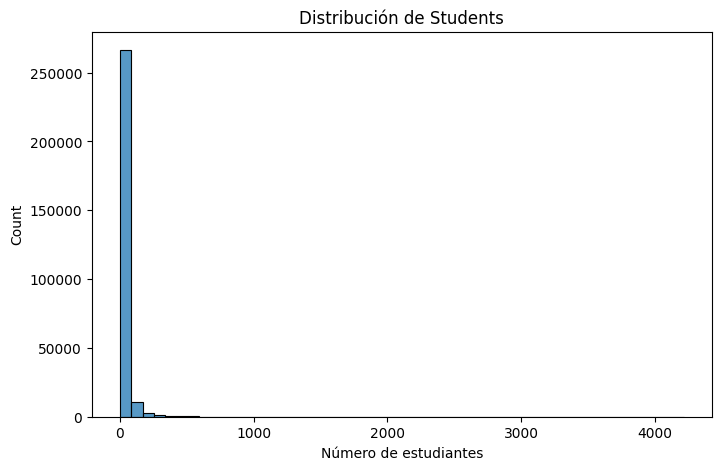

In [37]:
print("Análisis univariado de Students:")
print(df["Students"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["Students"], bins=50)
plt.title("Distribución de Students")
plt.xlabel("Número de estudiantes")
plt.show()


Para observar con más detalle la forma de la distribución en el rango
donde se concentra la mayoría de los registros, se genera una segunda
versión del histograma limitada a valores de `Students` menores o iguales
a 400. Esto no elimina los valores atípicos del análisis.

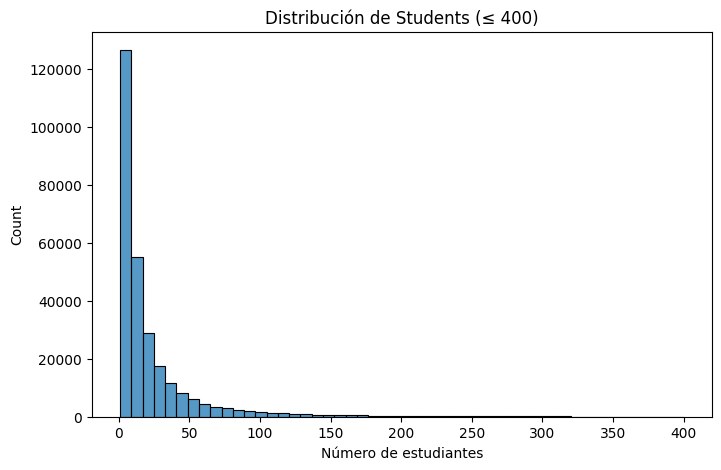

In [38]:
# Distribución de una columna numérica por debajo de un límite determinado
def plot_bounded_distribution(column_name, upper_limit, bin_count=50):
    data_filtrada = df[df[column_name] <= upper_limit][column_name]

    plt.figure(figsize=(8, 5))
    sns.histplot(data_filtrada, bins=bin_count)
    plt.title(f"Distribución de {column_name} (≤ {upper_limit})")
    plt.xlabel("Número de estudiantes")
    plt.show()


plot_bounded_distribution("Students", upper_limit=400)

Para la distribución del atributo Sex, podemos observar que el histograma obtenido tiene de manera muy pareja la cantidad de hombres (Male) y mujeres (Female). Sin embargo vemos que las Mujeres sobresalen del histograma con 141762.

Análisis univariado de Sex:
Sex
Female    141762
Male      140452
Name: count, dtype: int64


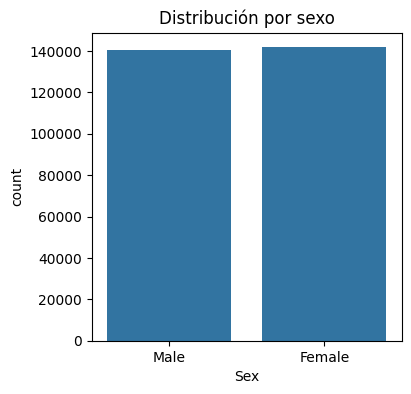

In [39]:
print("Análisis univariado de Sex:")
print(df["Sex"].value_counts())

plt.figure(figsize=(4, 4))
sns.countplot(x="Sex", data=df)
plt.title("Distribución por sexo")
plt.show()

En la distribución del atributo Academic Degree se observa una agrupación de datos más grande en Bacherlor's Degree y la tendencia es que siguiendo la secuencia de estudios Bacherlor's Degree -> Master Degree -> PhD el número va bajando, asemejándose a la realidad, el cual sabemos que a más grado de estudios menos gente.

Análisis univariado de Academic Degree:
Academic Degree
Bachelor's Degree                                           181922
Master Degree                                                56709
Specialty                                                    15245
Technical or Comercial Studies, and Finished High School     11106
PhD                                                          10755
Normal Bachelor's Degree                                      6477
Name: count, dtype: int64


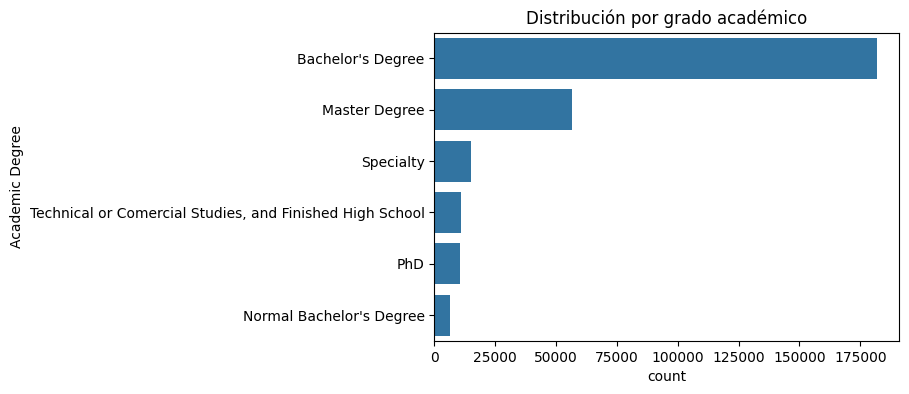

In [40]:
print("Análisis univariado de Academic Degree:")
print(df["Academic Degree"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(y="Academic Degree", data=df, order=df["Academic Degree"].value_counts().index)
plt.title("Distribución por grado académico")
plt.show()


Siguiendo con la distribución del atributo State, observamos una clara preferencia a los estados Estado de México y Ciudad de México. Apegándonos a la realidad, estos estados son los que más gente concentran en la República Méxicana, no es de extrañarse que la tendencia favoreciera a estos estados.

Análisis univariado por State:
State
Estado de México                   27203
Ciudad de México                   23098
Puebla                             21072
Veracruz de Ignacio de la Llave    16552
Jalisco                            16224
Guanajuato                         12975
Nuevo León                         12906
Chiapas                            11259
Zacatecas                          10867
Michoacán de Ocampo                 9853
Tamaulipas                          9826
Coahuila de Zaragoza                8401
Baja California                     8291
Hidalgo                             7684
Yucatán                             7179
Querétaro                           6743
Sinaloa                             6627
San Luis Potosí                     6321
Sonora                              6307
Morelos                             5929
Chihuahua                           5826
Tabasco                             5740
Oaxaca                              5576
Guerrero            

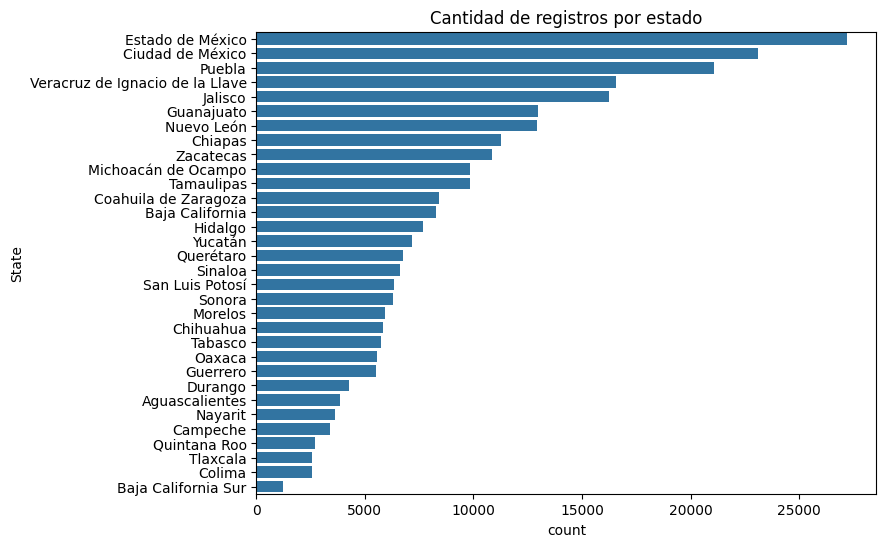

In [41]:
print("Análisis univariado por State:")
print(df["State"].value_counts())

plt.figure(figsize=(8, 6))
orden_estados = df["State"].value_counts().index
sns.countplot(y="State", data=df, order=orden_estados)
plt.title("Cantidad de registros por estado")
plt.show()

### Análisis bivariado

Para este análisis vamos a tomar la relación de los atributos Students y Sex. El análisis sería Numérico con Categórico. Sabemos con anterioridad que tenemos un número similar de estudiantes hombre y mujeres. ¿Habrá una brecha en la matrícula entre ellos o está balanceada la matrícula?

Podemos observar que en el boxplot muestra la distribución de este análisis bivariado casi idéntico pero si ponemos atención a los datos que donde se obtiene `mean`, `median` y `sum` la cual corresponde a la Media, Mediana y Suma total nos encontramos lo siguiente.

| Sexo |Media|Mediana | Suma total |
|------|---------|----------| -----------|
|Female|26.93 |11.0|3,817,060|
|Male   |22.88|9.0 |3,214,105|

Se observa que:


*   La mediana femenina (11) es ~22% más alta que la masculina (9).
*   La media femenina es ~18% más alta.
* La suma total de matrícula femenina es ~18.8% mayor que la masculina (3.82M vs 3.21M)

El hecho de que las tres observaciones apunten en la misma dirección, sugiere que es un patrón con una tendencia sistemática. En promedio para este análisis los registros de matrícula femenina son poco más grandes que la de los hombres.


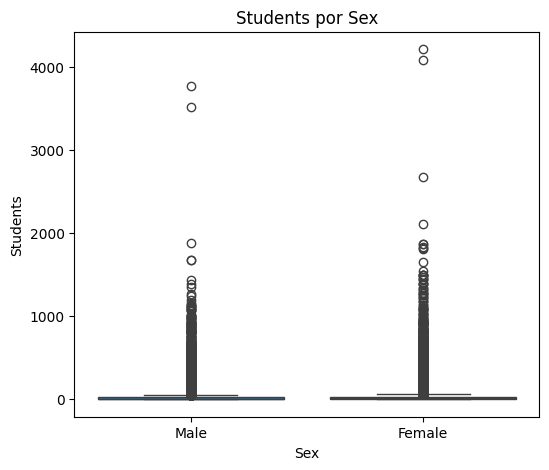

             mean  median      sum
Sex                               
Female  26.925833    11.0  3817060
Male    22.884010     9.0  3214105


In [42]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="Sex", y="Students", data=df)
plt.title("Students por Sex")
plt.show()

print(df.groupby("Sex")["Students"].agg(["mean", "median", "sum"]))

Para este otro análisis vamos tomar los atributos Sex y Academic Degree. Vimos que hay una tendencia hacía el número de mujeres en la matrícula, veamos que sucede si exploramos la concentración de Sexo en los niveles académicos.

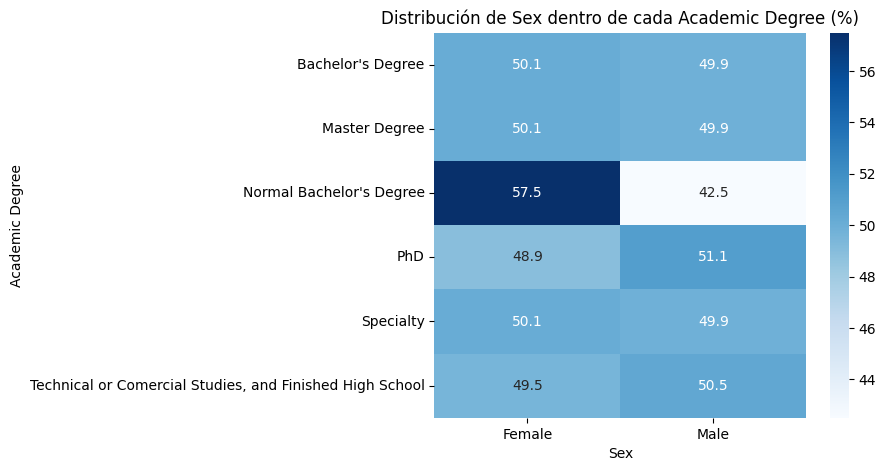

Sex                                                 Female  Male
Academic Degree                                                 
Bachelor's Degree                                     50.1  49.9
Master Degree                                         50.1  49.9
Normal Bachelor's Degree                              57.5  42.5
PhD                                                   48.9  51.1
Specialty                                             50.1  49.9
Technical or Comercial Studies, and Finished Hi...    49.5  50.5


In [43]:
tabla_cruzada = pd.crosstab(df["Academic Degree"], df["Sex"], normalize="index") * 100

plt.figure(figsize=(6, 5))
sns.heatmap(tabla_cruzada, annot=True, fmt=".1f", cmap="Blues")
plt.title("Distribución de Sex dentro de cada Academic Degree (%)")
plt.show()

print(tabla_cruzada.round(1))

Podemo observar que casi todos los niveles de grado de escolaridad están empatados, la diferencia es que en PhD el porcentaje se inclina a los hombres, pero donde se ve una diferencia sustancial es en Normal Bachelor's Degree con 57.5% mujeres vs 42.5% hombres, una brecha de 15 puntos porcentuales cuando todo lo demás está a menos de 2 puntos.

### Vista multivariada

Entre los 10 estados con mayor matrícula, `Bachelor's Degree`
domina consistentemente la composición, representando entre
aproximadamente 65% y 79% del total según el estado, lo cual es
coherente con que la licenciatura es el nivel predominante en la
educación superior mexicana en cualquier entidad con volumen alto de
matrícula.


In [44]:
top_estados = (
    df.groupby("State")["Students"].sum().sort_values(ascending=False).head(10).index
)

subset = df[df["State"].isin(top_estados)]
tabla = subset.pivot_table(
    index="State", columns="Academic Degree", values="Students", aggfunc="sum"
)
tabla = tabla.loc[top_estados]

tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

print("Bachelor's Degree por estado (top 10):")
print(tabla_pct["Bachelor's Degree"].round(1).sort_values(ascending=False))

print("\nComposición de Puebla:")
print(tabla_pct.loc["Puebla"].round(1))

Bachelor's Degree por estado (top 10):
State
Veracruz de Ignacio de la Llave    79.1
Jalisco                            78.9
Estado de México                   76.8
Tamaulipas                         76.2
Nuevo León                         75.0
Chiapas                            73.9
Ciudad de México                   73.1
Guanajuato                         72.8
Michoacán de Ocampo                72.3
Puebla                             65.4
Name: Bachelor's Degree, dtype: float64

Composición de Puebla:
Academic Degree
Bachelor's Degree                                           65.4
Master Degree                                               18.0
Normal Bachelor's Degree                                     2.6
PhD                                                          1.6
Specialty                                                    2.9
Technical or Comercial Studies, and Finished High School     9.5
Name: Puebla, dtype: float64


Puebla presenta la proporción más baja de licenciatura del grupo (65%),
compensada con una proporción de Master Degree superior al resto
(18%), lo que sugiere una oferta de posgrado proporcionalmente más
desarrollada en esa entidad respecto a los demás estados con alta
matrícula.

<table>
<tr>
<td>

| Estado | Bachelor's Degree (%) |
|---|---|
| Veracruz de Ignacio de la Llave | 79.1 |
| Jalisco | 78.9 |
| Estado de México | 76.8 |
| Tamaulipas | 76.2 |
| Nuevo León | 75.0 |
| Chiapas | 73.9 |
| Ciudad de México | 73.1 |
| Guanajuato | 72.8 |
| Michoacán de Ocampo | 72.3 |
| Puebla | 65.4 |

</td>
<td>

| Grado académico | Porcentaje (%) |
|---|---|
| Bachelor's Degree | 65.4 |
| Master Degree | 18.0 |
| Technical or Comercial Studies, and Finished High School | 9.5 |
| Specialty | 2.9 |
| Normal Bachelor's Degree | 2.6 |
| PhD | 1.6 |

</td>
</tr>
</table>


Ciudad de México destaca en `Specialty`. Su segmento se ve más grande (8%) que en cualquier otro estado, coherente con que CDMX concentra los grandes hospitales, escuela y programas de especialidad que suelen ofertar las instituciones de educación.

| Estado                         | Specialty (%) |
|---------------------------------|-----------------|
| Ciudad de México                 | 8.0             |
| Jalisco                          | 4.7             |
| Tamaulipas                       | 2.9             |
| Puebla                           | 2.9             |
| Nuevo León                       | 2.7             |
| Estado de México                 | 2.1             |
| Guanajuato                       | 1.8             |
| Michoacán de Ocampo               | 1.6             |
| Veracruz de Ignacio de la Llave  | 1.4             |
| Chiapas                          | 1.4             |

In [45]:
print("\nSpecialty en Ciudad de México:")
print(f"{tabla_pct.loc['Ciudad de México', 'Specialty']:.1f}%")

print("\nSpecialty por estado (top 10), de mayor a menor:")
print(tabla_pct["Specialty"].round(1).sort_values(ascending=False))


Specialty en Ciudad de México:
8.0%

Specialty por estado (top 10), de mayor a menor:
State
Ciudad de México                   8.0
Jalisco                            4.7
Tamaulipas                         2.9
Puebla                             2.9
Nuevo León                         2.7
Estado de México                   2.1
Guanajuato                         1.8
Michoacán de Ocampo                1.6
Veracruz de Ignacio de la Llave    1.4
Chiapas                            1.4
Name: Specialty, dtype: float64


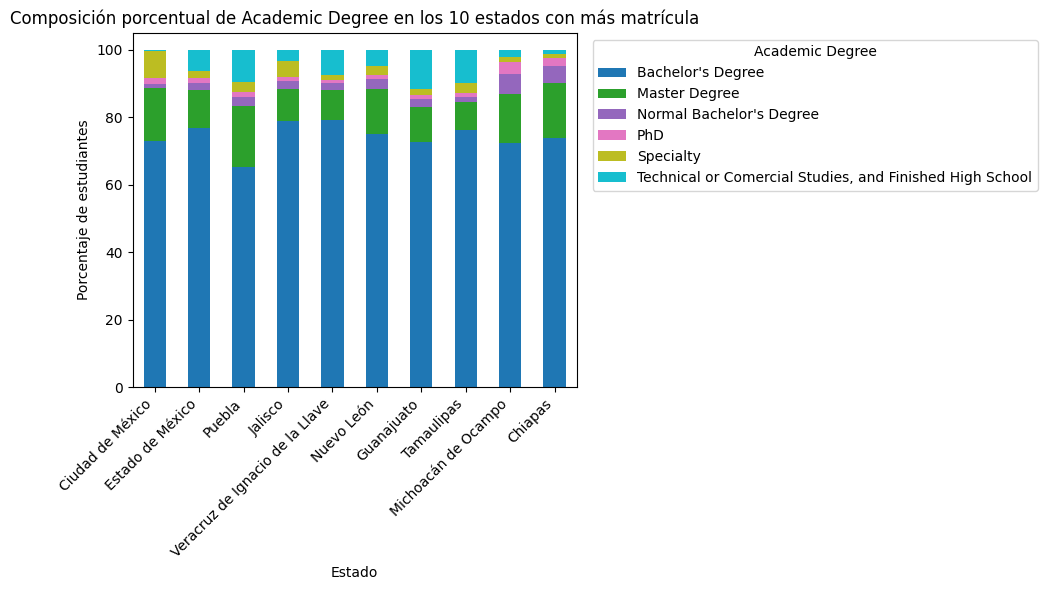

In [46]:
top_estados = (
    df.groupby("State")["Students"].sum().sort_values(ascending=False).head(10).index
)

subset = df[df["State"].isin(top_estados)]
tabla = subset.pivot_table(
    index="State", columns="Academic Degree", values="Students", aggfunc="sum"
)
tabla = tabla.loc[top_estados]  # conservar el orden por tamaño total

tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100

tabla_pct.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab10")
plt.title("Composición porcentual de Academic Degree en los 10 estados con más matrícula")
plt.ylabel("Porcentaje de estudiantes")
plt.xlabel("Estado")
plt.legend(title="Academic Degree", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Cierre

El dataset que se escogió está limpio de duplicados y valores faltantes o imposibles.
No se encontraron registros duplicados, ni valores nulos, ni valores de `Students` negativos o iguales
a cero. Esto no significa que los datos originales de ANUIES carezcan de estos problemas, sino que el motor de agregación (cubo OLAP) detrás de
DataMéxico omite combinaciones sin reporte en lugar de representarlas
como cero o nulo explícito es un hallazgo sobre cómo se construyó el
dataset, no solo un resultado negativo.

Algo importante a destacar es que  la matrícula femenina supera a la masculina de forma consistente a mediana, la media y la suma total de `Students` son entre 18% y 22%
mayores para el sexo femenino que para el masculino. Esta diferencia era invisible en el boxplot y solo se
detectó al revisar los estadísticos numéricos, lo que subraya la
importancia de no concluir solo a partir de la inspección visual de una
gráfica.

Los datos se obtuvieron de DataMéxico, un
  distribuidor secundario del dato original de ANUIES. Un análisis más
  riguroso debería contrastar contra la publicación directa de ANUIES
  (Anuario Estadístico de Educación Superior) para verificar que no haya
  disparidad introducidas en el proceso de agregación de DataMéxico.

 El dataser no
  permite distinguir entre instituciones públicas y privadas, ni por
  modalidad de estudio, lo que limita la profundidad de cualquier
  conclusión sobre políticas públicas de educación superior.

## Referencias

Asociación Nacional de Universidades e Instituciones de Educación Superior
(ANUIES). (s.f.). *Anuario Estadístico de la Población Escolar en
Educación Superior*. Recuperado de https://www.anuies.mx

Secretaría de Economía e Instituto Nacional de Estadística y Geografía
(INEGI). (s.f.). *DataMéxico*. Consultado el 18 de septiembre de 2026,
en [COMPLETAR: pega aquí el enlace exacto de tu consulta en DataMéxico]

Secretaría de Educación Pública (SEP). (s.f.). *Formato 911: Estadística
básica del Sistema Educativo Nacional* [Instrumento de recolección de
datos utilizado como fuente primaria por ANUIES].

Gobierno de México. (s.f.). *Términos y condiciones de uso*. Recuperado
de [COMPLETAR: pega el enlace exacto que revisaste en tu captura de TyC]

MIT Communication Lab. (s.f.). *Coding and Comment Style*. Broad
Institute of MIT and Harvard. Recuperado de
https://mitcommlab.mit.edu/broad/commkit/coding-and-comment-style/

## Declaración de uso de IA

Para la elaboración de esta práctica se utilizó un asistente de
inteligencia artificial (Claude, de Anthropic) como herramienta de apoyo.
A continuación se detalla, con transparencia, en qué consistió ese apoyo:

*  Orientación para identificar qué tipo de datos disponibles en
  DataMéxico podían cumplir con los requisitos de la práctica (mínimo de
  registros, atributos, variables numéricas/categóricas, etc.)

* Redacción y ajuste de estilo de los textos explicativos e
  interpretativos en Markdown, a partir de los resultados y gráficas
  generadas.

* Redacción de código en Python (pandas, matplotlib, seaborn) para la
  verificación de estructura, el análisis de calidad de datos, y las
  visualizaciones univariadas, bivariadas y multivariadas.